In [17]:
using JuMP
using GLPK
using Test

In [2]:
# production plants (Bottling plant)
plants = ["Mobile","Montgomery", "CollegePark","Marietta","BatonRouge","NewOrleans","Chattanooga","Cleveland"]

8-element Array{String,1}:
 "Mobile"
 "Montgomery"
 "CollegePark"
 "Marietta"
 "BatonRouge"
 "NewOrleans"
 "Chattanooga"
 "Cleveland"

In [4]:
size(plants)

(8,)

In [5]:
num_plants=length(plants)

8

In [6]:
markets=["Alaska",
"Arizona",
"Arkansas",
"Delaware",
"DistrictofColumbia",
"Iowa",
"NewYork",
"NorthCarolina",
"Ohio",
"Vermont",
"WestVirginia",
"Wisconsin"]

12-element Array{String,1}:
 "Alaska"
 "Arizona"
 "Arkansas"
 "Delaware"
 "DistrictofColumbia"
 "Iowa"
 "NewYork"
 "NorthCarolina"
 "Ohio"
 "Vermont"
 "WestVirginia"
 "Wisconsin"

In [7]:
num_markets=length(markets)

12

In [23]:
## we assume 30000 bottles per employee per year
capacity=[15500*30000, 500*30000, 5000*30000, 2000*30000, 400*30000, 5600*30000, 700*30000, 200*30000]

8-element Array{Int64,1}:
 465000000
  15000000
 150000000
  60000000
  12000000
 168000000
  21000000
   6000000

In [9]:
##
demand = [7223049,
75649521,
48550034,
10667455,
6742306,
36190697,
155218597,
154474824,
137053667,
4815076,
31352658,
59628048]

12-element Array{Int64,1}:
   7223049
  75649521
  48550034
  10667455
   6742306
  36190697
 155218597
 154474824
 137053667
   4815076
  31352658
  59628048

In [10]:
distance=[4327 1591 493 1058 966 967 1372 712 864 1528 864 1094;
          4284 1680 446 891 799 924 1205 546 697 1362 697 927;
          4278 1742 508 740 696 901 1087 395 617 1211 579 904;
          4250 1749 515 737 645 873 1069 392 589 1208 551 877;
          4263 1392 387 1238 1142 988 1517 911 1006 1667 1012 1086;
          5086 2929 1738 1349 1270 1811 1601 1303 1241 1609 954 1097;
          4152 1687 453 695 598 775 973 453 505 1123 468 779;
          4170 1716 482 665 569 804 944 424 476 1094 438 797]

8×12 Array{Int64,2}:
 4327  1591   493  1058   966   967  1372   712   864  1528   864  1094
 4284  1680   446   891   799   924  1205   546   697  1362   697   927
 4278  1742   508   740   696   901  1087   395   617  1211   579   904
 4250  1749   515   737   645   873  1069   392   589  1208   551   877
 4263  1392   387  1238  1142   988  1517   911  1006  1667  1012  1086
 5086  2929  1738  1349  1270  1811  1601  1303  1241  1609   954  1097
 4152  1687   453   695   598   775   973   453   505  1123   468   779
 4170  1716   482   665   569   804   944   424   476  1094   438   797

In [11]:
# Fuel=[22.6;26.3;37;26.4;24.9;26.4;17.8;36;26.4;17.1;37.6;23.3]# * solve for three fuel level
#* three fuel level scenario
#* robust optimization
#* use the sample we did in class to solve the problem







In [12]:
using JuMP, GLPK

myModel = Model(with_optimizer(GLPK.Optimizer))

#cost_per_mile = 1.00
N,M = size(distance)

@variable(myModel, x[i=1:num_plants,1:num_markets] >= 0, Int)

@constraint(myModel, capacity_contraints[i=1:num_plants],sum(x[i,:]) <= capacity[i])
@constraint(myModel, demand_contraints[j=1:num_markets],sum(x[:,j]) >= demand[j])


@objective(myModel, Min, sum(x[i,j]* distance[i,j] for i = 1:N for j = 1:M))

myModel 

A JuMP Model
Minimization problem with:
Variables: 96
Objective function type: GenericAffExpr{Float64,VariableRef}
`GenericAffExpr{Float64,VariableRef}`-in-`MathOptInterface.GreaterThan{Float64}`: 12 constraints
`GenericAffExpr{Float64,VariableRef}`-in-`MathOptInterface.LessThan{Float64}`: 8 constraints
`VariableRef`-in-`MathOptInterface.GreaterThan{Float64}`: 96 constraints
`VariableRef`-in-`MathOptInterface.Integer`: 96 constraints
Model mode: AUTOMATIC
CachingOptimizer state: EMPTY_OPTIMIZER
Solver name: GLPK
Names registered in the model: capacity_contraints, demand_contraints, x

In [13]:
@time begin
    status = optimize!(myModel)  
end

println("Objective value: ", JuMP.objective_value(myModel))
println("Optimal solution is x = \n", JuMP.value.(x))

  9.577128 seconds (28.06 M allocations: 1.402 GiB, 9.67% gc time)
Objective value: 6.87028071315e11
Optimal solution is x = 
[7.223049e6 6.3649521e7 4.8550034e7 0.0 0.0 3.6190697e7 1.26270916e8 0.0 1.37053667e8 0.0 0.0 4.4628048e7; 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 1.5e7; 0.0 0.0 0.0 0.0 0.0 0.0 0.0 1.5e8 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 1.0667455e7 6.742306e6 0.0 1.947681e6 4.474824e6 0.0 4.815076e6 3.1352658e7 0.0; 0.0 1.2e7 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0 2.1e7 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0 6.0e6 0.0 0.0 0.0 0.0 0.0]


In [14]:
sol = JuMP.value.(x)
obj = JuMP.objective_value(myModel)

6.87028071315e11

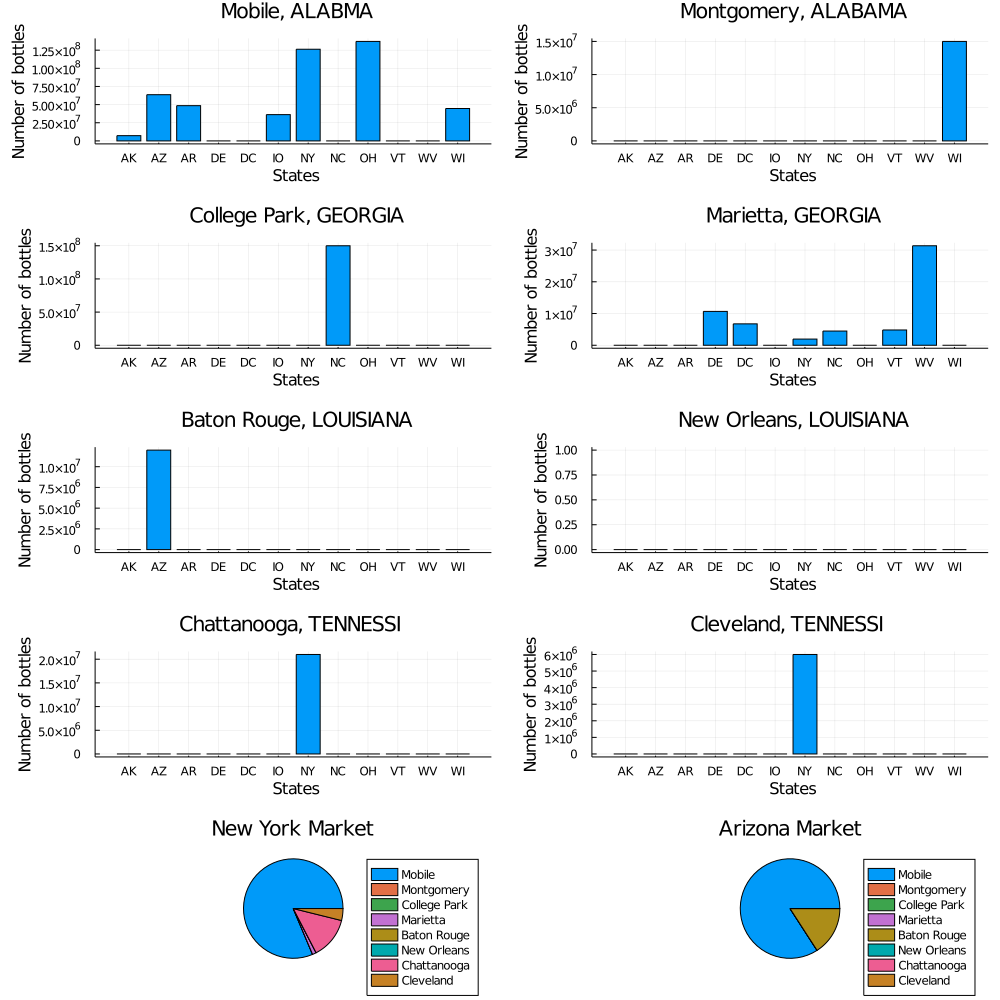

In [27]:
using Plots

l = @layout[a b; c d; e f; g  h; i j]
p1_1 = Plots.bar(["AK","AZ","AR","DE","DC","IO","NY","NC","OH","VT","WV","WI"],sol[1,:],title=" Mobile, ALABMA",xlabel=" States",ylabel="Number of bottles",legend=false)
p2_1= Plots.bar(["AK","AZ","AR","DE","DC","IO","NY","NC","OH","VT","WV","WI"],sol[2,:],title=" Montgomery, ALABAMA",xlabel=" States",ylabel="Number of bottles",legend=false)
p3_1 = Plots.bar(["AK","AZ","AR","DE","DC","IO","NY","NC","OH","VT","WV","WI"],sol[3,:],title=" College Park, GEORGIA",xlabel=" States",ylabel="Number of bottles",legend=false)
p4_1= Plots.bar(["AK","AZ","AR","DE","DC","IO","NY","NC","OH","VT","WV","WI"],sol[4,:],title=" Marietta, GEORGIA",xlabel=" States",ylabel="Number of bottles",legend=false)
p5_1 = Plots.bar(["AK","AZ","AR","DE","DC","IO","NY","NC","OH","VT","WV","WI"],sol[5,:],title=" Baton Rouge, LOUISIANA",xlabel=" States",ylabel="Number of bottles",legend=false)
p6_1= Plots.bar(["AK","AZ","AR","DE","DC","IO","NY","NC","OH","VT","WV","WI"],sol[6,:],title=" New Orleans, LOUISIANA",xlabel=" States",ylabel="Number of bottles",legend=false)
p7_1 = Plots.bar(["AK","AZ","AR","DE","DC","IO","NY","NC","OH","VT","WV","WI"],sol[7,:],title="Chattanooga, TENNESSI ",xlabel=" States",ylabel="Number of bottles",legend=false)
p8_1= Plots.bar(["AK","AZ","AR","DE","DC","IO","NY","NC","OH","VT","WV","WI"],sol[8,:],title="Cleveland, TENNESSI ",xlabel=" States",ylabel="Number of bottles",legend=false)



p6_2 = Plots.pie(["Mobile","Montgomery","College Park","Marietta", "Baton Rouge", "New Orleans", "Chattanooga", "Cleveland"],sol[:,7],title="New York Market")
p0_2 = Plots.pie(["Mobile","Montgomery","College Park","Marietta", "Baton Rouge", "New Orleans", "Chattanooga", "Cleveland"],sol[:,2],title="Arizona Market")


plot(p1_1,p2_1,p3_1,p4_1,p5_1,p6_1,p7_1,p8_1,p6_2,p0_2,layout=l,size=(1000,1000))


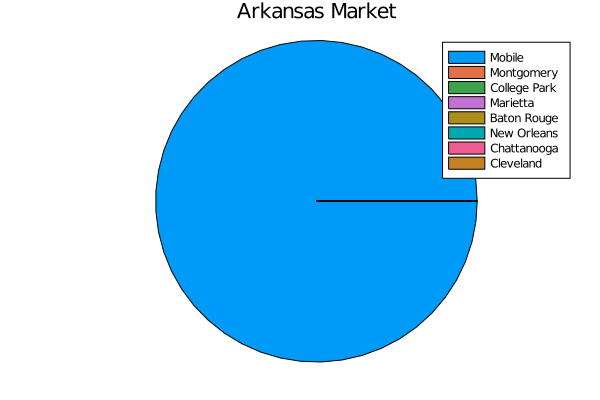

In [24]:
p0_2 = Plots.pie(["Mobile","Montgomery","College Park","Marietta", "Baton Rouge", "New Orleans", "Chattanooga", "Cleveland"],sol[:,3],title="Arkansas Market")

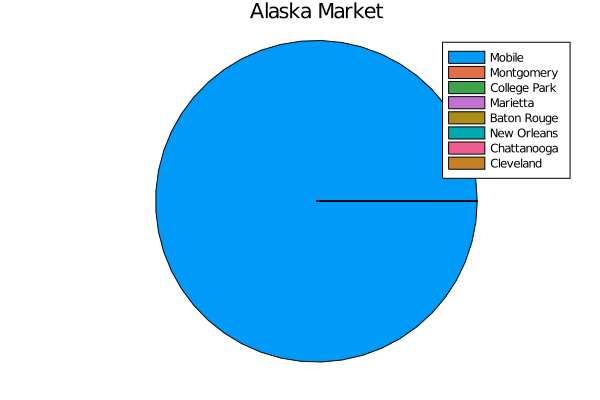

In [25]:
p6_2 = Plots.pie(["Mobile","Montgomery","College Park","Marietta", "Baton Rouge", "New Orleans", "Chattanooga", "Cleveland"],sol[:,1],title="Alaska Market")

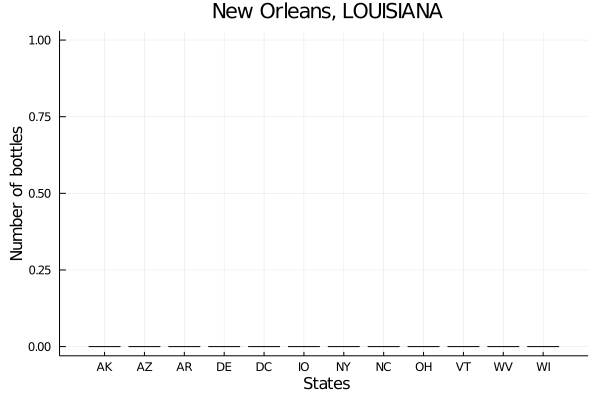

In [21]:
p6_1= Plots.bar(["AK","AZ","AR","DE","DC","IO","NY","NC","OH","VT","WV","WI"],sol[6,:],title=" New Orleans, LOUISIANA",xlabel=" States",ylabel="Number of bottles",legend=false)

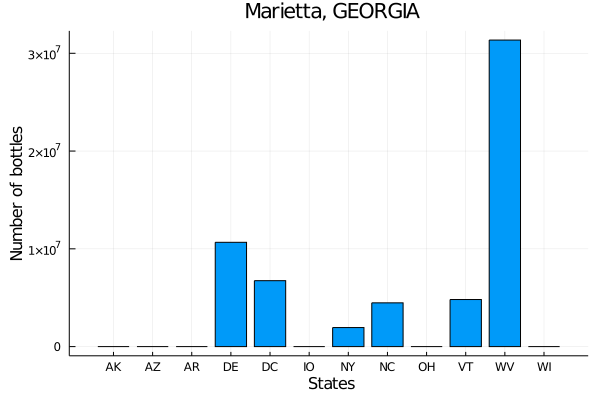

In [28]:
p4_1= Plots.bar(["AK","AZ","AR","DE","DC","IO","NY","NC","OH","VT","WV","WI"],sol[4,:],title=" Marietta, GEORGIA",xlabel=" States",ylabel="Number of bottles",legend=false)

- Plant like Mariatta Georgia with capacty of production equal to 60,000,000 serves several states like Delaware, DC, New York, North Carolina, VERMONT Whereas plants with higher production capacity like College Park, Georgia and New Orleans, Respectively 150000000 and 168000000 for  one state only New York, and zero.

- Thus Coca-Cola would make more profit buy increasing the production capacity of plant like Mariata Georgia, all things remaining equal 

- Arkansas is the the Market that is closest to all our production plants

- production plant Cleveland, Tennessi is the closest to all of our markets

- News Orleans, LOUISIANA is the Production Plant farther away to all our markets that why 




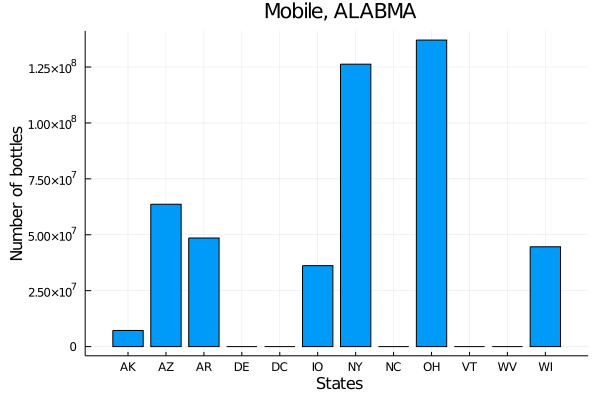

In [26]:
p1_1 = Plots.bar(["AK","AZ","AR","DE","DC","IO","NY","NC","OH","VT","WV","WI"],sol[1,:],title=" Mobile, ALABMA",xlabel=" States",ylabel="Number of bottles",legend=false)